# Stacking Ensemble

**base learner：**
- GBR、lightGBM、XGBoost、RandomForest、ExtraRandomTrees、SVR

**meta learner：**
- XGBoost

**Introduce the six most important features：**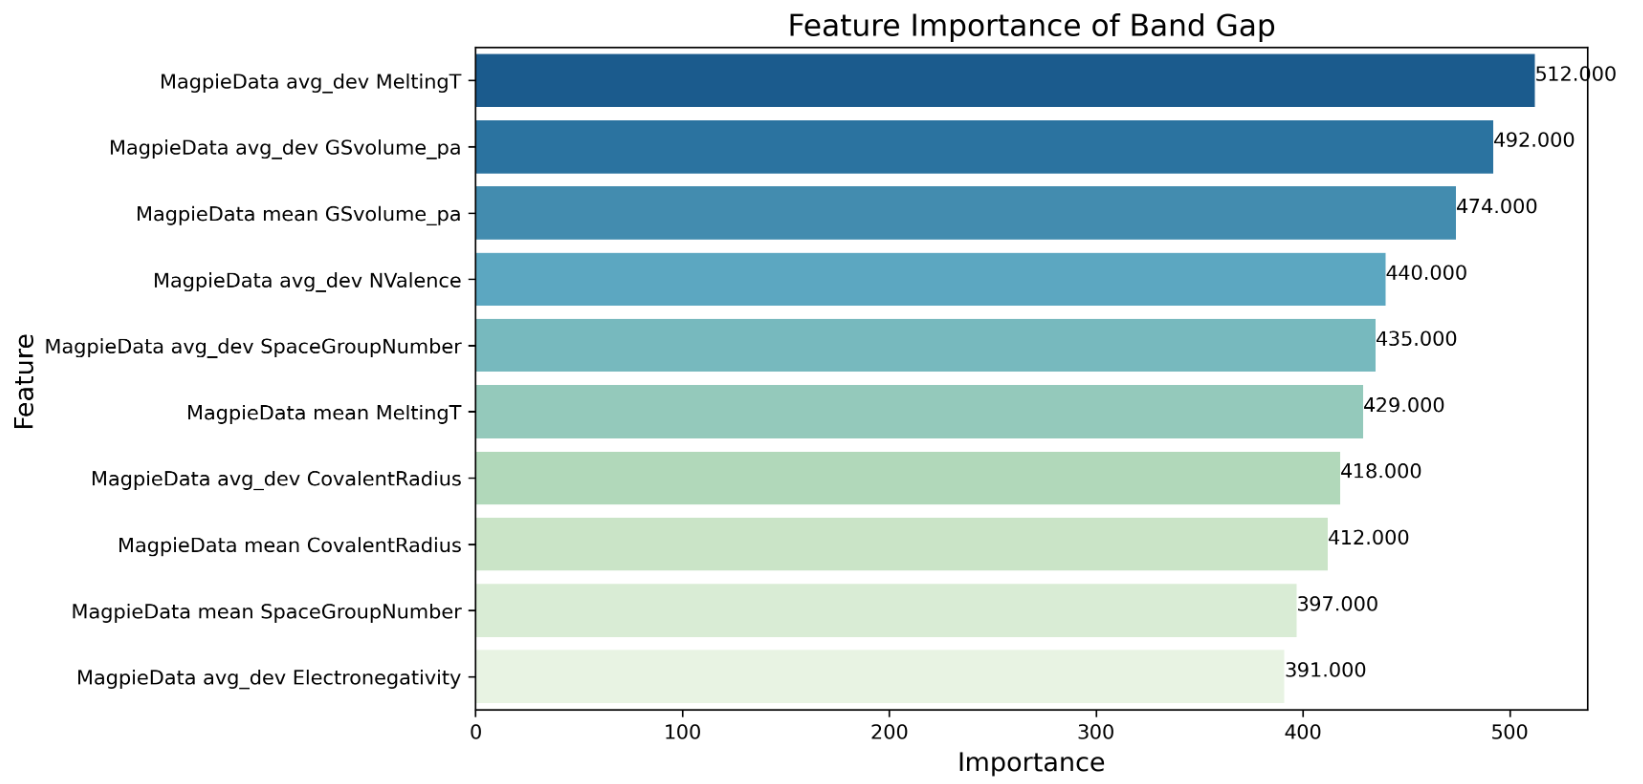

In [48]:
import os
import sys
import pandas as pd
import numpy as np
np.random.seed(42)
current_path = os.getcwd()
current_path

'c:\\Users\\Fortyfour\\Desktop\\graduation_design\\Scripts_git\\MixedDataTrain'

In [49]:
file_path = os.path.join(current_path, 'Stacking')
os.makedirs(file_path, exist_ok=True)

In [50]:
# Set random seed for reproducibility
RANDOM_SEED = 42
# 
FIG_SHOW = False

In [51]:
# To import the custom module from a specific path
sys.path.insert(0, os.path.join(current_path, '../'))
# Importing the custom module
from Utools.SingleModel import SingleModel

In [52]:
# Load data
file_dir = os.path.join(current_path, '../Data/composition_data/feature_data')
# dft data
dft_train = pd.read_csv(os.path.join(file_dir, 'dft', 'train.csv'))
dft_test = pd.read_csv(os.path.join(file_dir, 'dft', 'test.csv'))
# exp data
exp_train = pd.read_csv(os.path.join(file_dir, 'exp', 'train.csv'))
exp_test = pd.read_csv(os.path.join(file_dir, 'exp', 'test.csv'))

dft_train_X = dft_train.drop(columns=['composition', 'band_gap'])
dft_train_y = dft_train['band_gap']
exp_train_X = exp_train.drop(columns=['composition', 'band_gap'])
exp_train_y = exp_train['band_gap']
dft_test_X = dft_test.drop(columns=['composition', 'band_gap'])
dft_test_y = dft_test['band_gap']
exp_test_X = exp_test.drop(columns=['composition', 'band_gap'])
exp_test_y = exp_test['band_gap']


# Mixed test set
# due to the number of test samples in dft and exp have a large difference
# so we resample the dft test set:   dft:exp = 2:1
dft_test_X_subset = dft_test_X.sample(n=round(len(exp_test_X) * 2), random_state=RANDOM_SEED)
dft_test_y_subset = dft_test_y.loc[dft_test_X_subset.index]
# mix
test_X = pd.concat([dft_test_X_subset, exp_test_X], ignore_index=True)
test_y = pd.concat([dft_test_y_subset, exp_test_y], ignore_index=True)

In [53]:
dft_train_X.shape, exp_train_X.shape, test_X.shape, test_y.shape

((22220, 132), (3025, 132), (2271, 132), (2271,))

## Base Learners Train

In [54]:
from sklearn.base import clone
# Import sklearn models
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

In [55]:
# define dft_models with the best hyper parameters in the pervious step
dft_models = {
    # GBDT models
    'GBR': GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=10, 
    max_features=0.25, subsample=1.0, random_state=RANDOM_SEED),

    'LightGBM': LGBMRegressor(learning_rate=0.2, max_depth=-1, n_estimators=500,
    subsample=0.7, colsample_bytree=1.0,
    objective='regression', random_state=RANDOM_SEED, n_jobs=-1),

    'XGBoost': XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=500,
    colsample_bytree=0.7, subsample=1.0, reg_lambda=1.0, alpha=0.5, 
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1),

    # Random Forest models
    'RandomForest': RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_split=2, min_samples_leaf=1,
    max_features=0.25, random_state=RANDOM_SEED, n_jobs=-1),
    
    'ExtraRandomTrees': ExtraTreesRegressor(
    n_estimators=500, max_depth=None, min_samples_split=7, min_samples_leaf=1,
    max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1),
    
    'SVR': SVR(kernel='rbf', C=25, epsilon=0.07, gamma=0.01)
}

In [56]:
meta_train_X = pd.DataFrame()
meta_train_y = exp_train_y
dft_trained_models = {}
model_number = 0
model_nums = len(dft_models)

# train dft models and add the predictions to the exp train set
for model_name, model in dft_models.items():
    model_number += 1
    print(f"[{model_number}/{model_nums} - {model_name}] Training...")
    # train the model
    dft_model = SingleModel(clone(model), random_state=RANDOM_SEED)
    dft_model.train(dft_train_X, dft_train_y)
    y_pred = dft_model.predict(exp_train_X)
    meta_train_X[model_name] = y_pred
    # save the model
    dft_trained_models[model_name] = dft_model

[1/6 - GBR] Training...
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total= 1.7min
Model training completed!
[2/6 - LightGBM] Training...
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.1s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14285
[LightGBM] [Info] Number of data points in the train set: 22220, number of used features: 128
[LightGBM] [Info] Start training from score 2.309916
[Pipeline] ............. (step 2 of 2) Processing model, total=   2.7s
Model training completed!
[3/6 - XGBoost] Training...
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.1s


e:\software2\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Pipeline] ............. (step 2 of 2) Processing model, total=   5.0s
Model training completed!
[4/6 - RandomForest] Training...
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.1s
[Pipeline] ............. (step 2 of 2) Processing model, total=  29.2s
Model training completed!
[5/6 - ExtraRandomTrees] Training...
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=  23.5s
Model training completed!
[6/6 - SVR] Training...
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=11.0min
Model training completed!


In [57]:
meta_train_X.head()

,GBR,LightGBM,XGBoost,RandomForest,ExtraRandomTrees,SVR
0,1.075788,1.064258,1.053432,1.085427,1.086785,0.906145
1,0.862585,0.792044,0.932705,0.916720,0.921650,0.864818
2,0.710427,0.747946,0.645154,0.680453,0.556175,0.871437
3,0.677223,0.704903,0.702046,0.704093,0.704026,0.555740
4,1.700423,1.637089,1.764490,1.768813,1.566538,0.727319


In [58]:
# whether to use important features of exp as meta features
USE_IMPORTANT_FEAT = True
important_features = ['MagpieData avg_dev MeltingT', 'MagpieData avg_dev GSvolume_pa', 'MagpieData mean GSvolume_pa',
                      'MagpieData avg_dev NValence', 'MagpieData avg_dev SpaceGroupNumber', 'MagpieData mean MeltingT']


if USE_IMPORTANT_FEAT:
    important_features_train_df = exp_train_X[important_features].copy()
    meta_train_X = pd.concat([important_features_train_df, meta_train_X], axis=1)

    # add the important features to the test set
    meta_dft_test_X = dft_test_X[important_features].copy()
    meta_exp_test_X = exp_test_X[important_features].copy()
    meta_mix_test_X = test_X[important_features].copy()   
else:
    meta_dft_test_X = pd.DataFrame()
    meta_exp_test_X = pd.DataFrame()
    meta_mix_test_X = pd.DataFrame()


In [59]:
# add dft model predictions to the test set
for model_name, model in dft_trained_models.items():
    print(f"[{model_name}] Predicting...")
    # predict the test set
    y_pred = model.predict(dft_test_X)
    meta_dft_test_X[model_name] = y_pred
    # predict the mixed test set
    y_pred = model.predict(test_X)
    meta_mix_test_X[model_name] = y_pred
    # predict the exp test set
    y_pred = model.predict(exp_test_X)
    meta_exp_test_X[model_name] = y_pred

[GBR] Predicting...
[LightGBM] Predicting...
[XGBoost] Predicting...
[RandomForest] Predicting...


e:\software2\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\software2\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\software2\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[ExtraRandomTrees] Predicting...
[SVR] Predicting...


####################################################################################################
Training Stacking XGBoost on train data:
----------------------------------------------------------------------------------------------------
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   0.6s
Model training completed!
[Train_error] Evaluating Stacking XGBoost on train set:


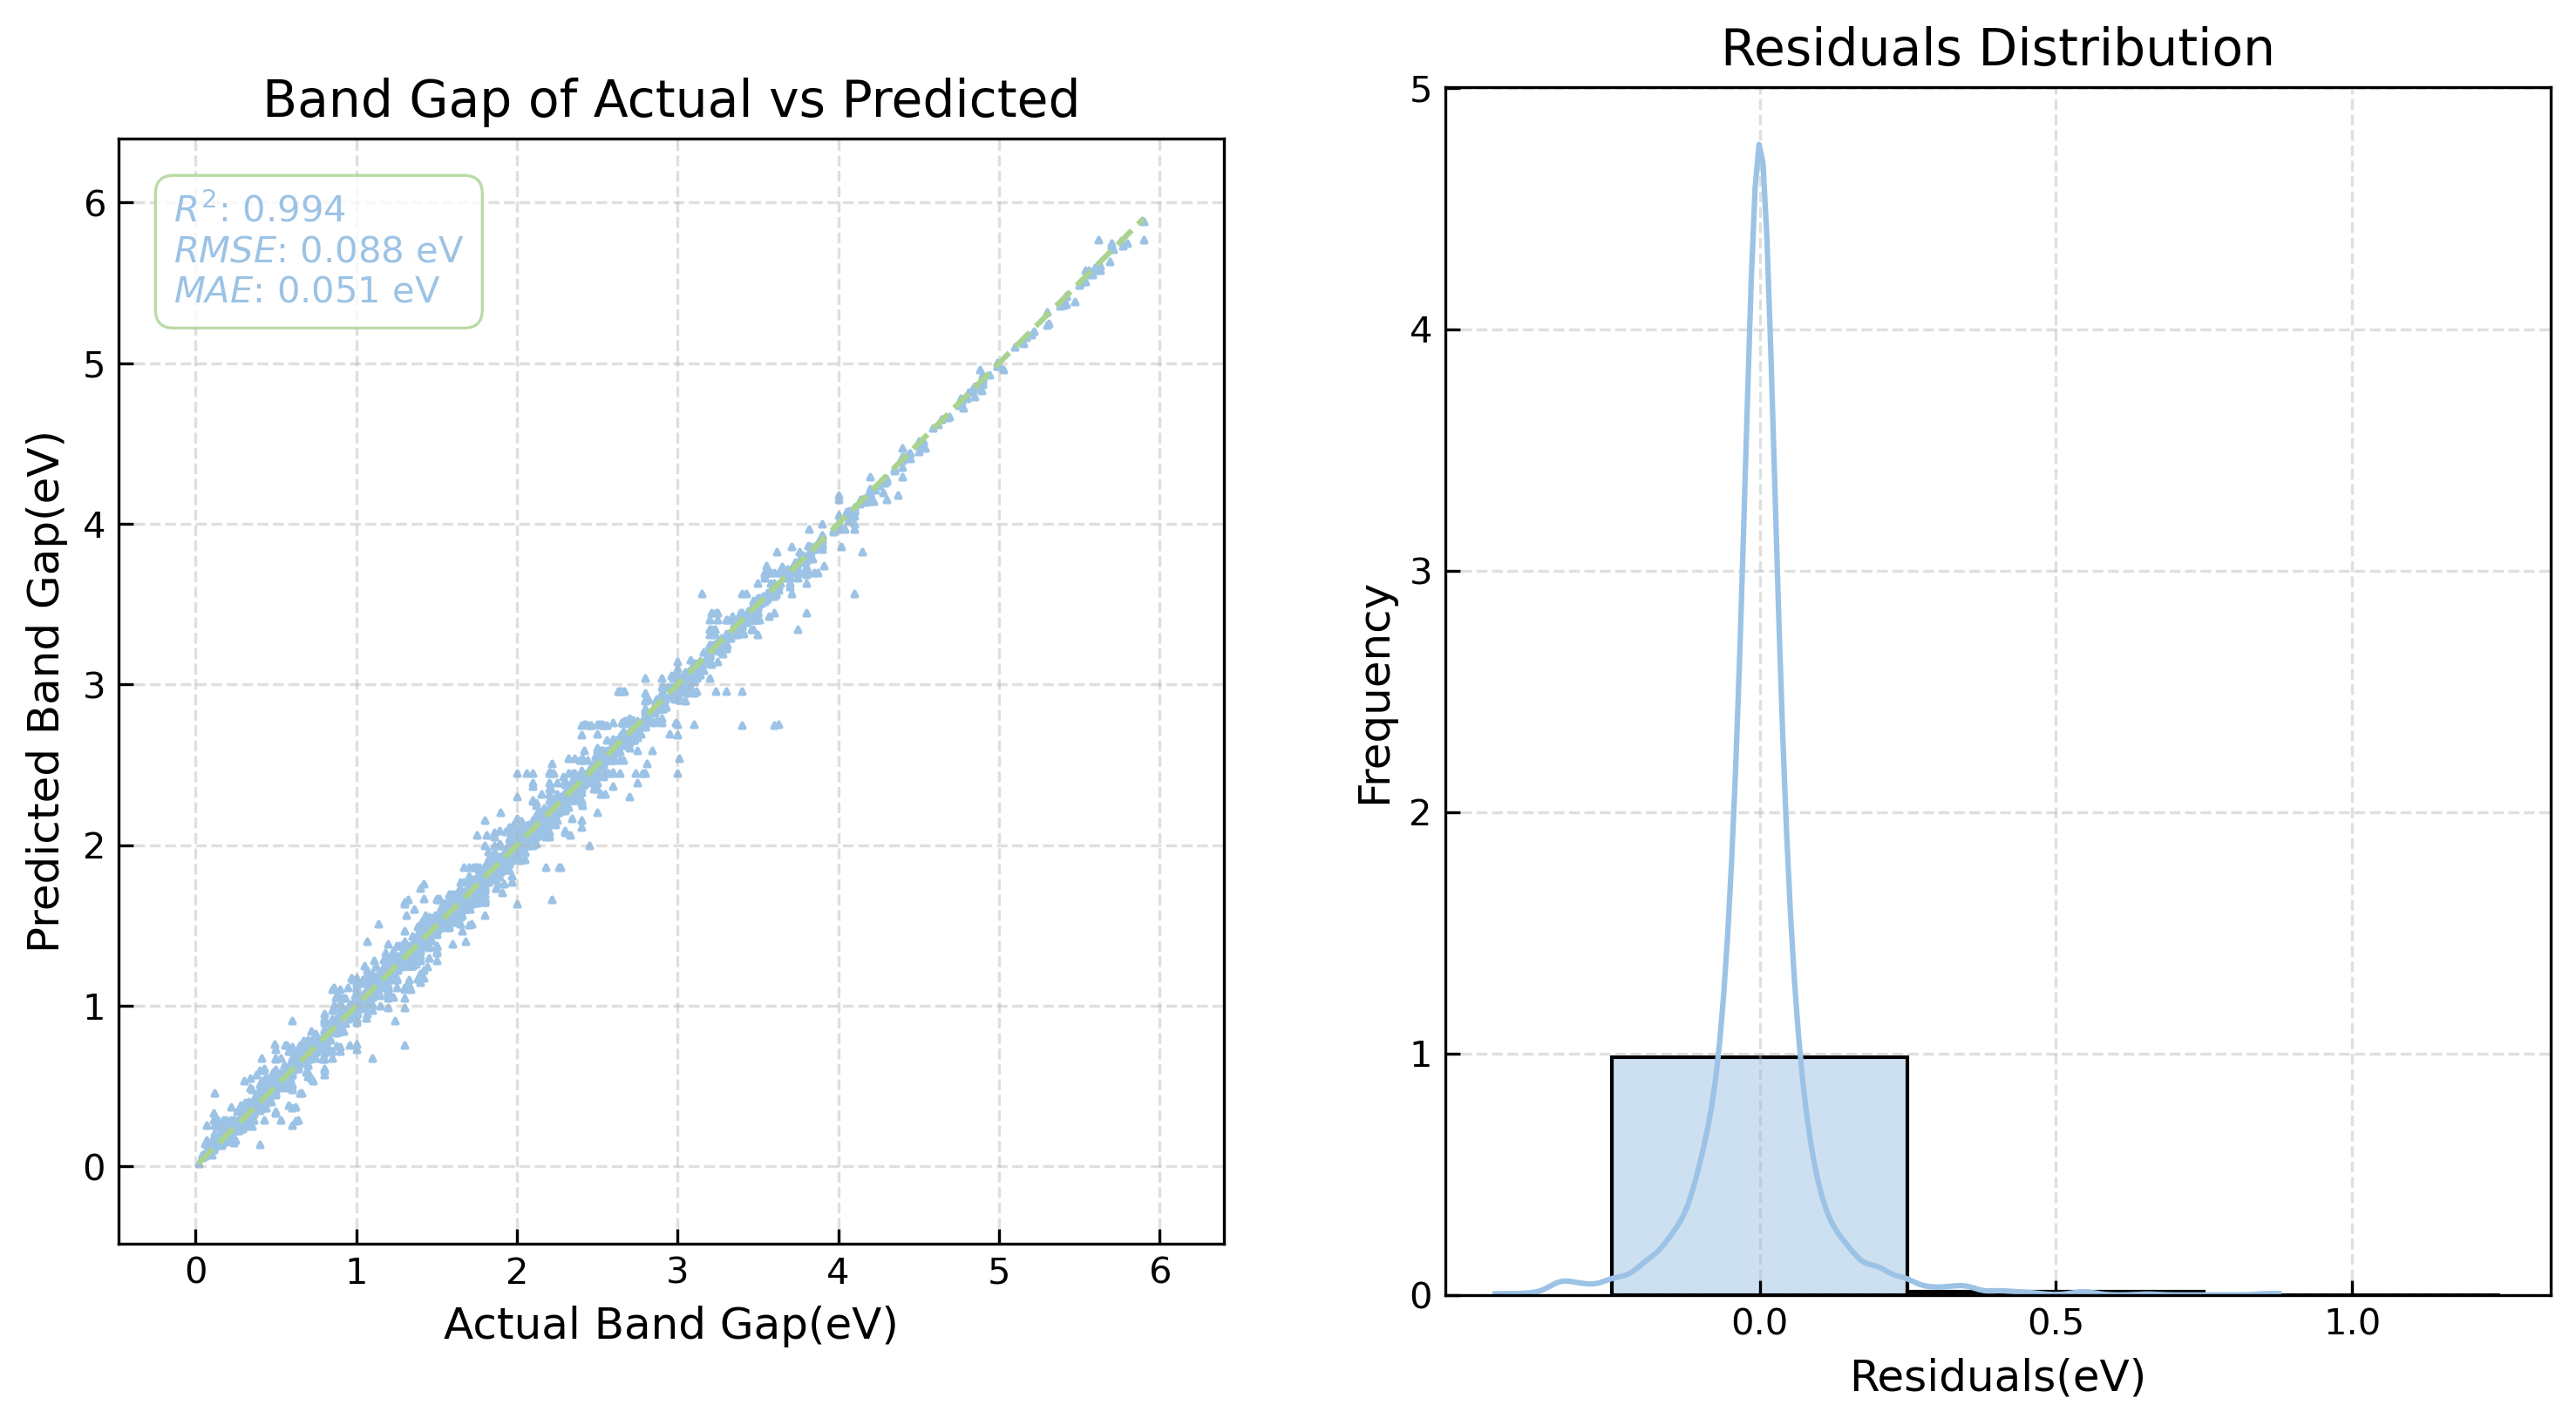


Model Evaluation Results:
Test set size: 3025
Test set: R²: 0.9945 RMSE: 0.0875 MAE: 0.0507 MAPE: 5.4276%
[Test Meta -> DFT] Evaluating Stacking XGBoost on DFT test set:


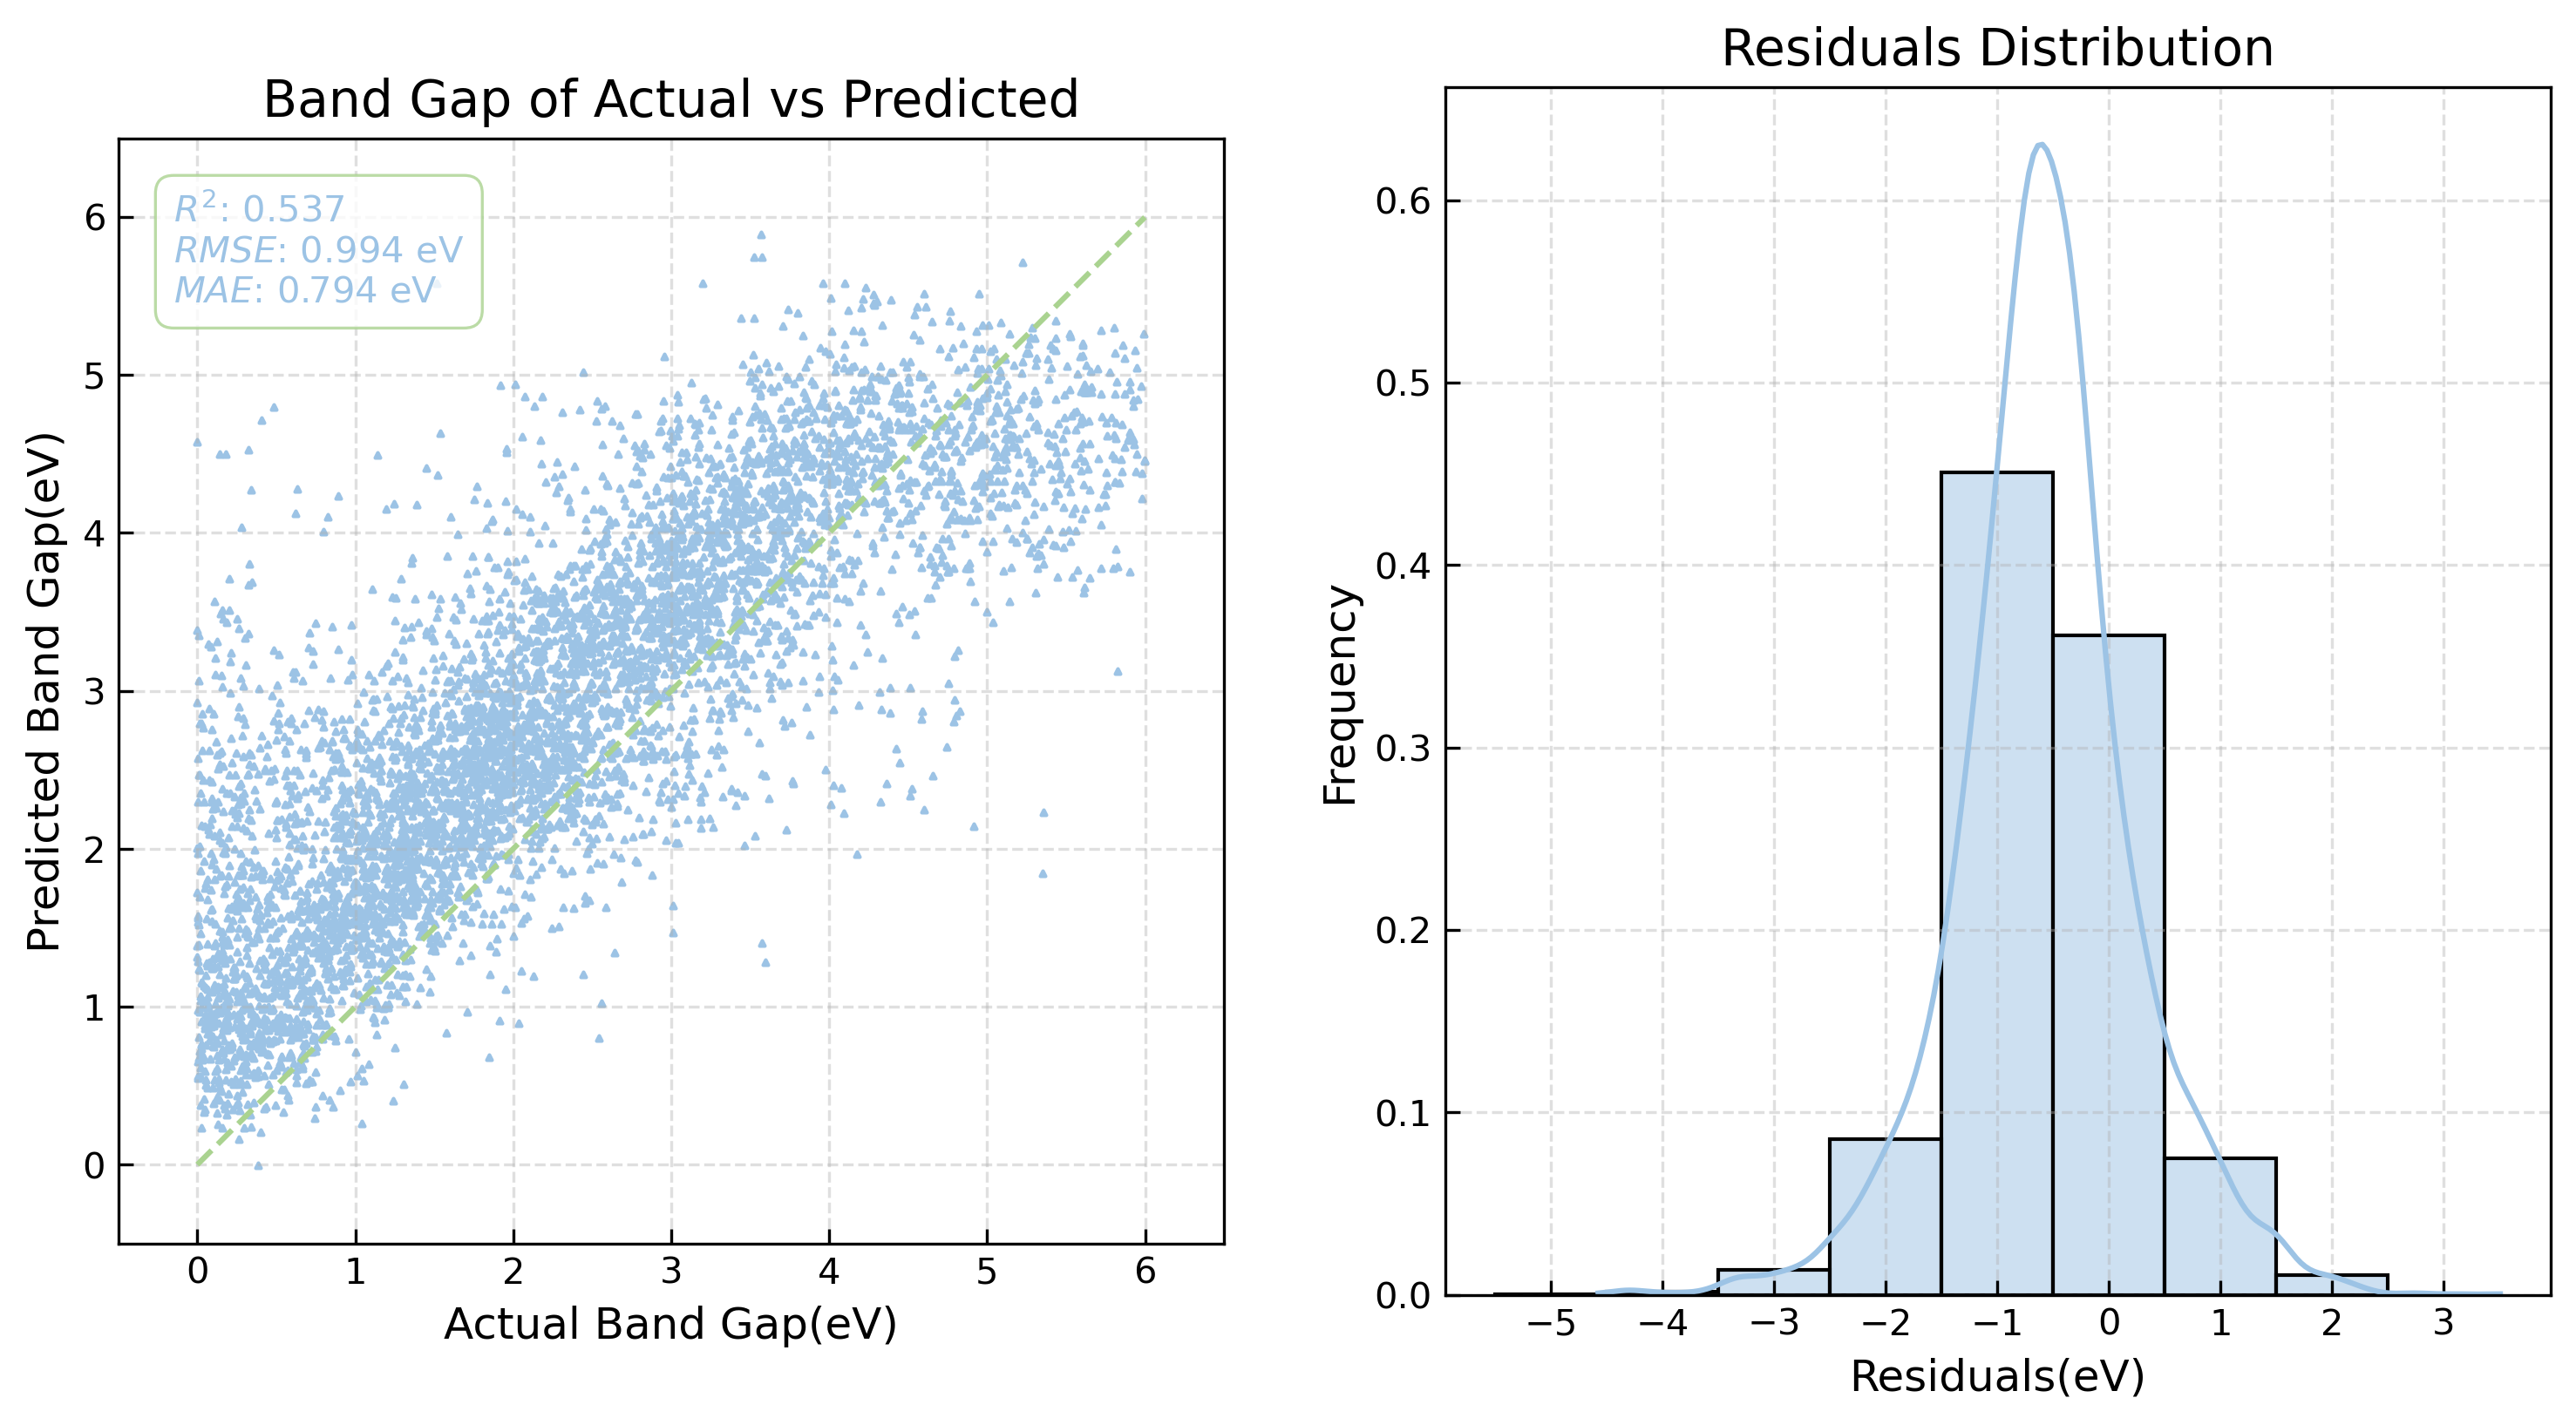


Model Evaluation Results:
Test set size: 5556
Test set: R²: 0.5372 RMSE: 0.9938 MAE: 0.7944 MAPE: 2463.6702%
[Test Meta -> EXP] Evaluating Stacking XGBoost on EXP test set:


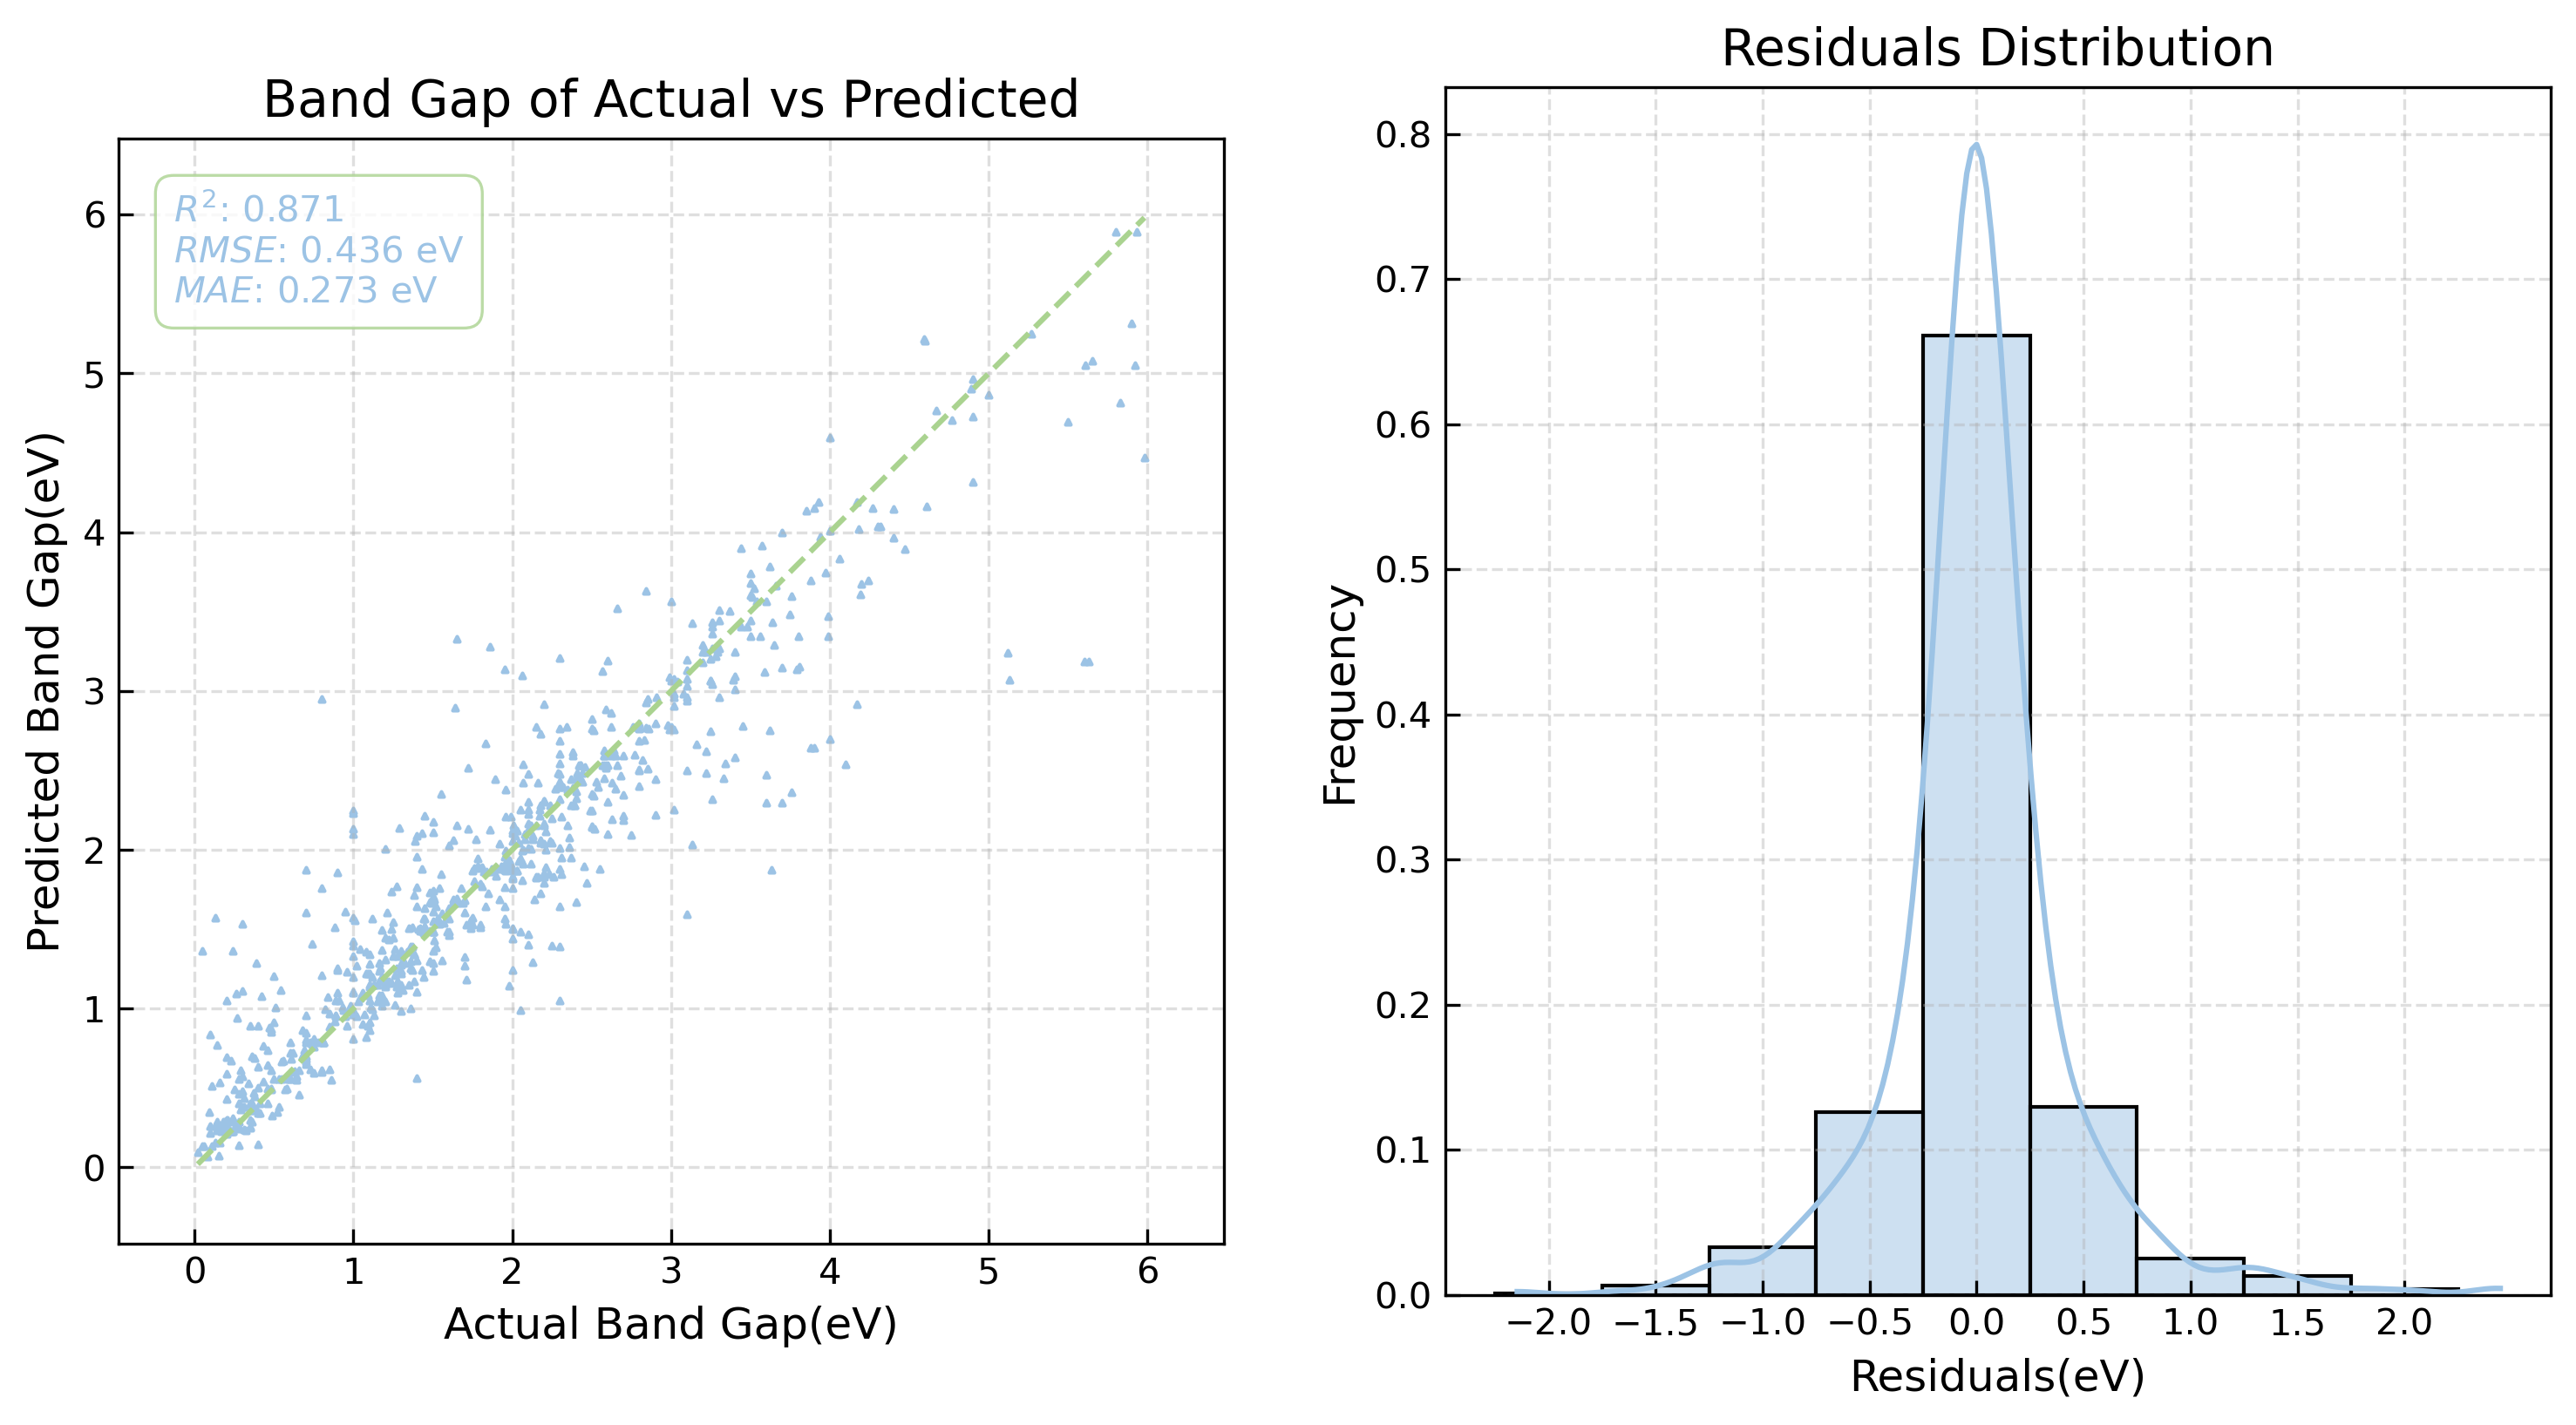


Model Evaluation Results:
Test set size: 757
Test set: R²: 0.8707 RMSE: 0.4355 MAE: 0.2726 MAPE: 30.6417%
[Test Meta -> MIX] Evaluating Stacking XGBoost on mixed test set:


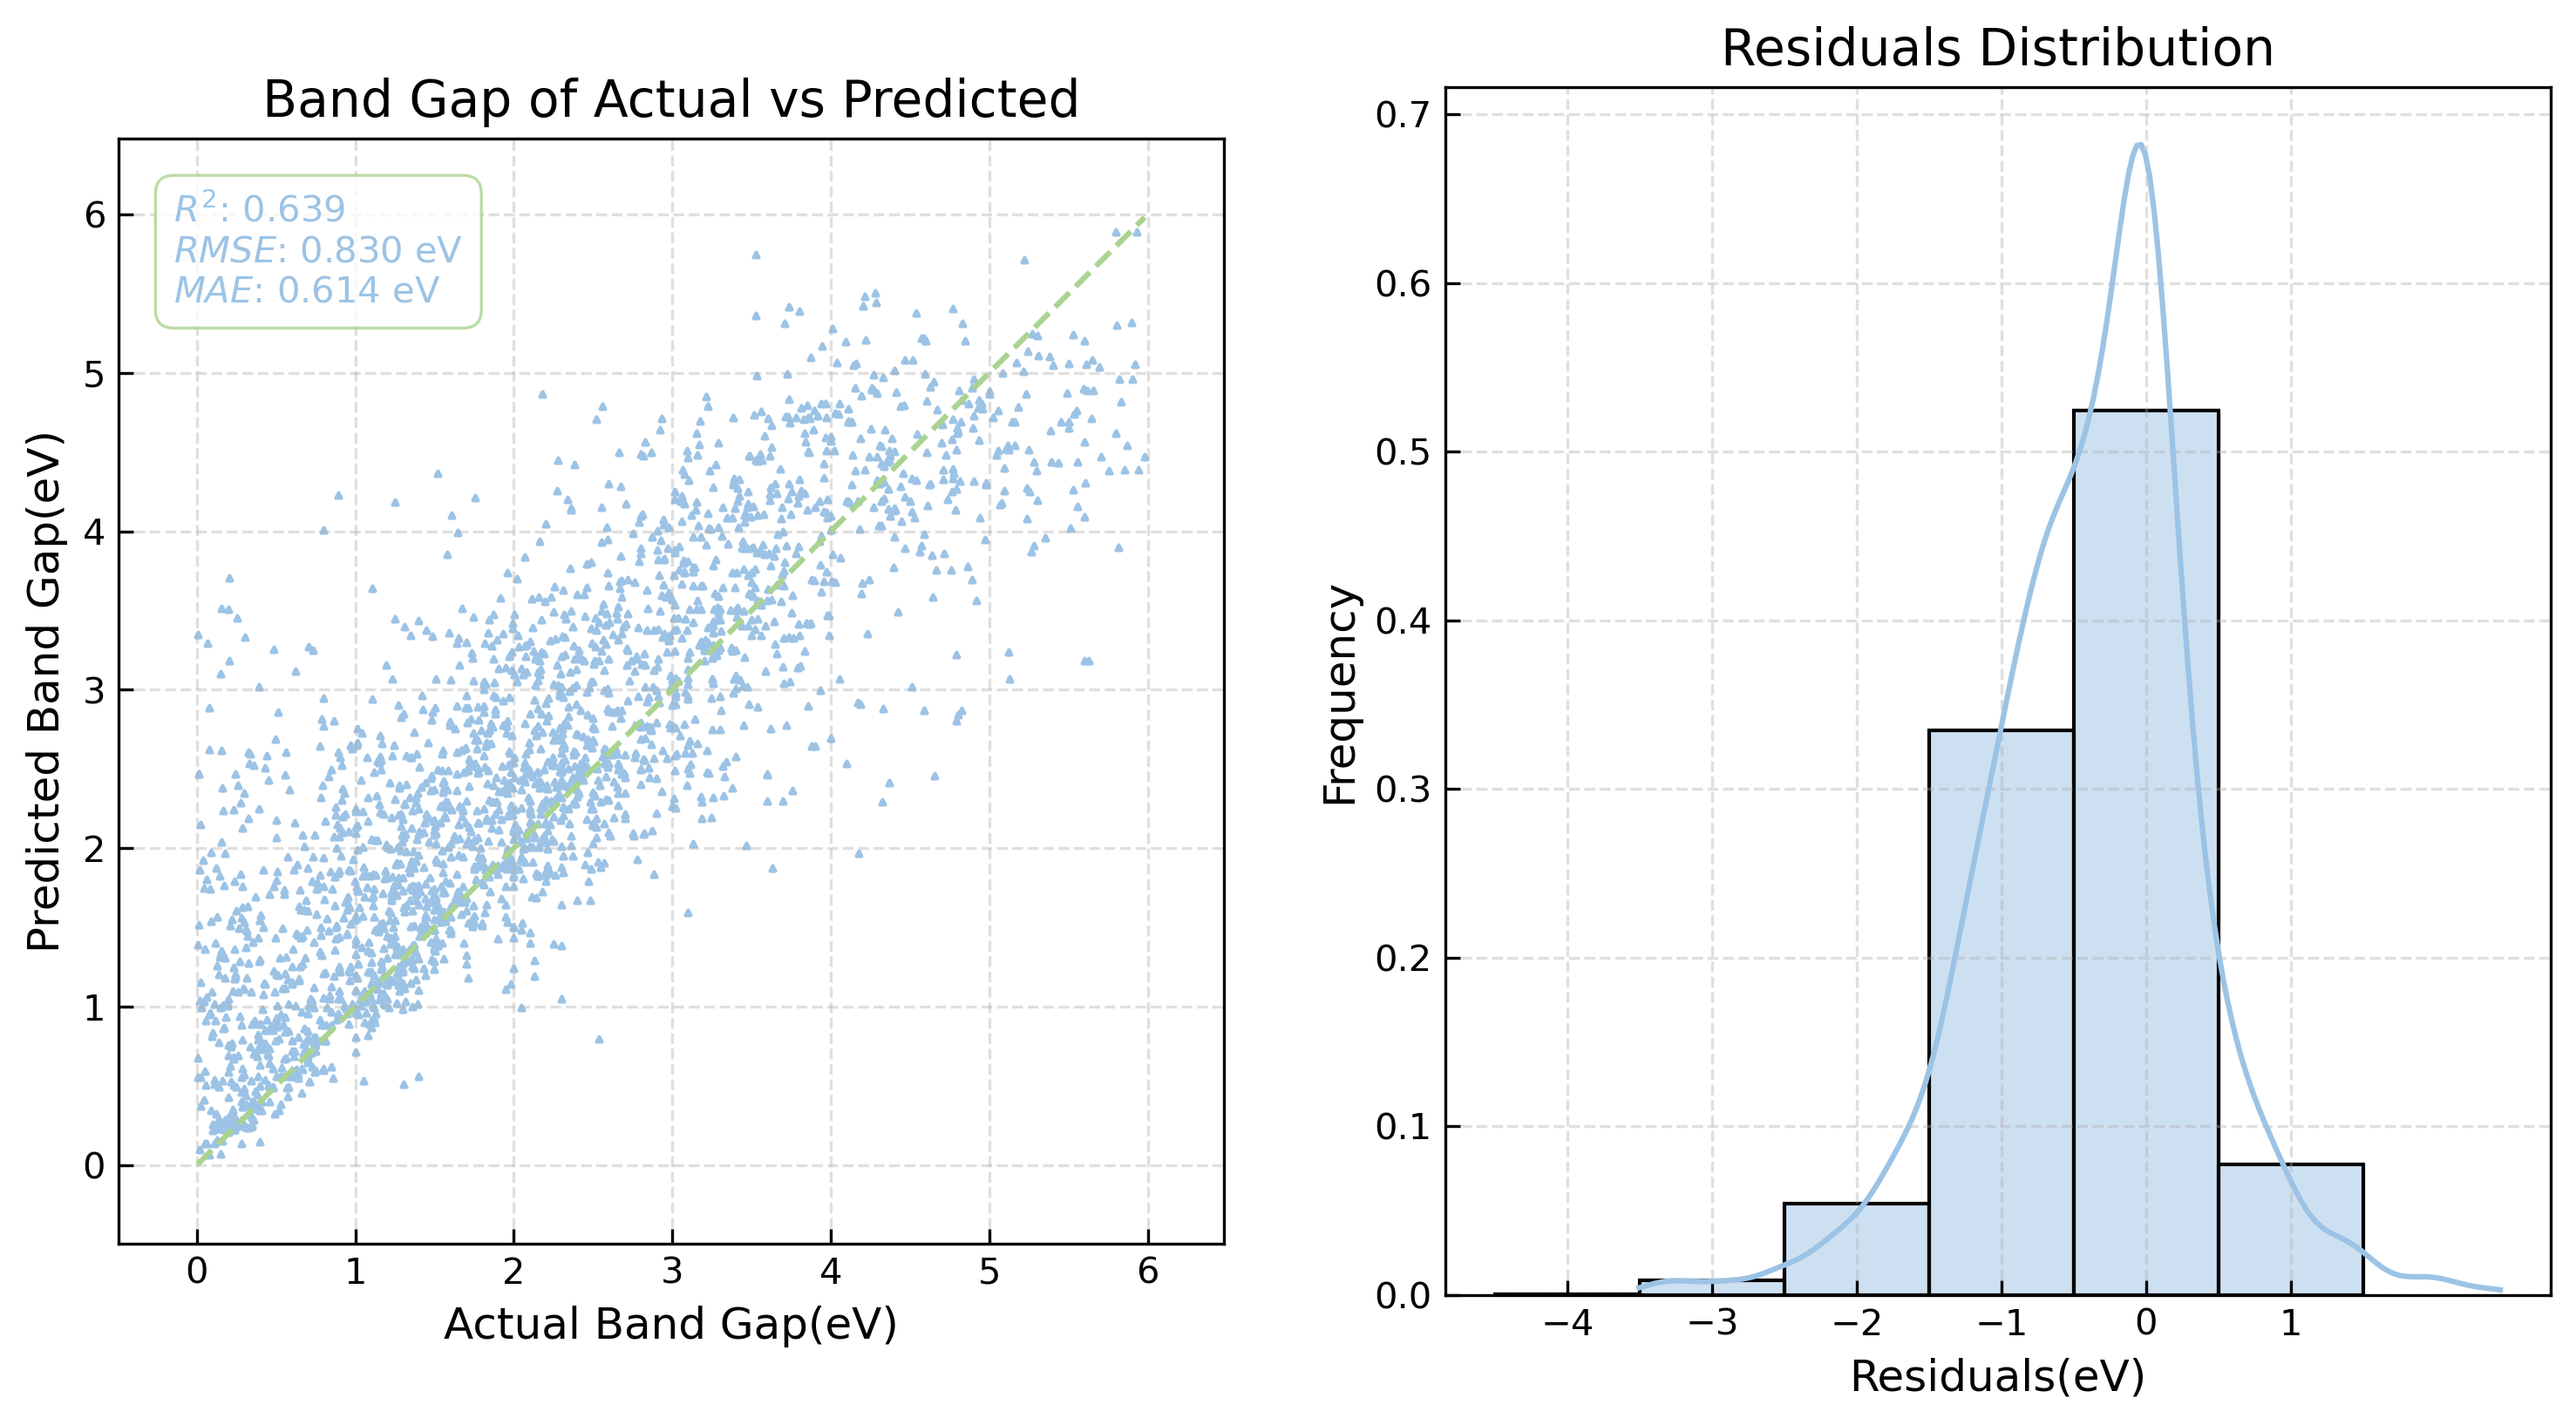


Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.6394 RMSE: 0.8302 MAE: 0.6136 MAPE: 159.7049%


,Model,Error_Type,Train_set,Test_set,R²,RMSE,MAE
0,Stacking XGBoost,Train,meta,meta,0.994471,0.087510,0.050733
1,Stacking XGBoost,Test,meta,dft,0.537206,0.993850,0.794383
2,Stacking XGBoost,Test,meta,exp,0.870737,0.435543,0.272570
3,Stacking XGBoost,Test,meta,mix,0.639421,0.830247,0.613598


In [63]:
# meta model training
# 
MODEL_NAME = 'Stacking XGBoost'
# Train the model with the best hyperparameters on the entire training set
xgboost = XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=500,
    colsample_bytree=0.7, subsample=0.9,
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1)
# record model metrics
model_metrics = pd.DataFrame(columns=['Model', 'Error_Type', 'Train_set', 'Test_set', 'R²', 'RMSE', 'MAE'])
# Train the model on mixed data
print("#" * 100)
print(f"Training {MODEL_NAME} on train data:")
print("-" * 100)

model = SingleModel(xgboost, random_state=RANDOM_SEED)
model.train(meta_train_X, meta_train_y)

# evaluate on the train set
print(f"[Train_error] Evaluating {MODEL_NAME} on train set:")
metrics = model.evaluate(meta_train_X, meta_train_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Train',
'Train_set': 'meta',
'Test_set': 'meta',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the dft test set
print(f"[Test Meta -> DFT] Evaluating {MODEL_NAME} on DFT test set:")
metrics = model.evaluate(meta_dft_test_X, dft_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'meta',
'Test_set': 'dft',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# evaluate on the exp test set
print(f"[Test Meta -> EXP] Evaluating {MODEL_NAME} on EXP test set:")
metrics = model.evaluate(meta_exp_test_X, exp_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'meta',
'Test_set': 'exp',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the mixed test set
print(f"[Test Meta -> MIX] Evaluating {MODEL_NAME} on mixed test set:")
metrics = model.evaluate(meta_mix_test_X, test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,    
'Error_Type': 'Test',
'Train_set': 'meta',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# save the model metrics to a csv file
model_metrics.to_csv(os.path.join(file_path, 'model_metrics.csv'), index=False)
model_metrics